# 04 — Red neuronal (Fase C, tarea 10)

Clasificación binaria **derroche en la hora siguiente** con PyTorch. Entrena con `data/gold/dataset_tarea9_final.csv` y guarda artefactos en `models/`.


# Face C - Modelo de IA

Tarea 10

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv('../data/gold/dataset_tarea9_final.csv', index_col=0, parse_dates=True)
df = df.dropna()

FEATURE_COLS = [
    'hora_del_dia', 'dia_de_la_semana', 'mes_del_ano',
    'temp_aula', 'hum_aula', 'pres_aula',
    'temp_exterior', 'nubosidad', 'hum_exterior', 'vel_viento',
    'elevacion_sol', 'acimut_sol',
    'calefaccion_encendida'
]
TARGET_COL = 'derroche_siguiente_hora'

X = df[FEATURE_COLS].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.int64)

print(f"Muestras: {len(X)}, Features: {X.shape[1]}")
print(f"Derroche sí: {y.sum()}, Derroche no: {len(y) - y.sum()} ({y.mean():.2%})")

Muestras: 3924, Features: 13
Derroche sí: 1058, Derroche no: 2866 (26.96%)


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_total = len(X)
idx = np.arange(n_total)
idx_train, idx_temp = train_test_split(idx, test_size=0.3, shuffle=False)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, shuffle=False)

X_train, X_val, X_test = X_scaled[idx_train], X_scaled[idx_val], X_scaled[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Derroche en test: {y_test.sum()} ({y_test.mean():.2%})")

Train: 2746, Val: 589, Test: 589
Derroche en test: 158 (26.83%)


In [4]:
class DerrocheDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64
train_ds = DerrocheDataset(X_train, y_train)
val_ds = DerrocheDataset(X_val, y_val)
test_ds = DerrocheDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [5]:
class RedDerroche(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev, h),
                nn.ReLU(),
                nn.BatchNorm1d(h),
                nn.Dropout(dropout)
            ])
            prev = h
        self.encoder = nn.Sequential(*layers)
        self.classifier = nn.Linear(prev, 1)

    def forward(self, x):
        x = self.encoder(x)
        return self.classifier(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RedDerroche(input_dim=X.shape[1]).to(device)

In [6]:
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
pos_weight = torch.tensor([pos_weight], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [7]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    preds, probs, targets = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs.extend(torch.sigmoid(logits).cpu().numpy().ravel())
            preds.extend((logits > 0).long().cpu().numpy().ravel())
            targets.extend(y_batch.numpy().ravel().astype(int))
    return np.array(preds), np.array(probs), np.array(targets)

EPOCHS = 1000
best_val_f1 = 0
history = {'train_loss': [], 'val_f1': []}

for epoch in range(EPOCHS):
    loss = train_epoch(model, train_loader, criterion, optimizer, device)
    _, _, y_val_true = evaluate(model, val_loader, device)
    pred_val, prob_val, _ = evaluate(model, val_loader, device)
    val_f1 = f1_score(y_val_true, pred_val, zero_division=0)
    scheduler.step(loss)
    history['train_loss'].append(loss)
    history['val_f1'].append(val_f1)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        import os
        os.makedirs('../models', exist_ok=True)
        torch.save(model.state_dict(), '../models/model_derroche_best.pt')
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss:.4f} - Val F1: {val_f1:.4f}")

Epoch 20/1000 - Loss: 0.2534 - Val F1: 0.8782
Epoch 40/1000 - Loss: 0.2125 - Val F1: 0.8784
Epoch 60/1000 - Loss: 0.1945 - Val F1: 0.8907
Epoch 80/1000 - Loss: 0.1744 - Val F1: 0.8893
Epoch 100/1000 - Loss: 0.1954 - Val F1: 0.8884
Epoch 120/1000 - Loss: 0.1841 - Val F1: 0.8889
Epoch 140/1000 - Loss: 0.1860 - Val F1: 0.8893
Epoch 160/1000 - Loss: 0.1982 - Val F1: 0.8876
Epoch 180/1000 - Loss: 0.1799 - Val F1: 0.8853
Epoch 200/1000 - Loss: 0.1849 - Val F1: 0.8845
Epoch 220/1000 - Loss: 0.1938 - Val F1: 0.8876
Epoch 240/1000 - Loss: 0.1762 - Val F1: 0.8893
Epoch 260/1000 - Loss: 0.2098 - Val F1: 0.8893
Epoch 280/1000 - Loss: 0.2005 - Val F1: 0.8871
Epoch 300/1000 - Loss: 0.2009 - Val F1: 0.8893
Epoch 320/1000 - Loss: 0.1703 - Val F1: 0.8858
Epoch 340/1000 - Loss: 0.1886 - Val F1: 0.8871
Epoch 360/1000 - Loss: 0.1779 - Val F1: 0.8893
Epoch 380/1000 - Loss: 0.1704 - Val F1: 0.8822
Epoch 400/1000 - Loss: 0.1846 - Val F1: 0.8876
Epoch 420/1000 - Loss: 0.1967 - Val F1: 0.8845
Epoch 440/1000 - 

In [8]:
model.load_state_dict(torch.load('../models/model_derroche_best.pt', map_location=device))
pred_test, prob_test, y_test_true = evaluate(model, test_loader, device)

accuracy = accuracy_score(y_test_true, pred_test)
precision = precision_score(y_test_true, pred_test, zero_division=0)
recall = recall_score(y_test_true, pred_test, zero_division=0)
f1 = f1_score(y_test_true, pred_test, zero_division=0)
roc_auc = roc_auc_score(y_test_true, prob_test) if y_test_true.sum() > 0 else 0

print("Test")
print(f"Accuracy:   {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("\nMatriz de confusión:")
print(confusion_matrix(y_test_true, pred_test))
print("\nClassification report:")
print(classification_report(y_test_true, pred_test, target_names=['No derroche', 'Derroche']))

Test
Accuracy:   0.9066
Precision: 0.8047
Recall:    0.8608
F1-Score:  0.8318
ROC-AUC:   0.9526

Matriz de confusión:
[[398  33]
 [ 22 136]]

Classification report:
              precision    recall  f1-score   support

 No derroche       0.95      0.92      0.94       431
    Derroche       0.80      0.86      0.83       158

    accuracy                           0.91       589
   macro avg       0.88      0.89      0.88       589
weighted avg       0.91      0.91      0.91       589



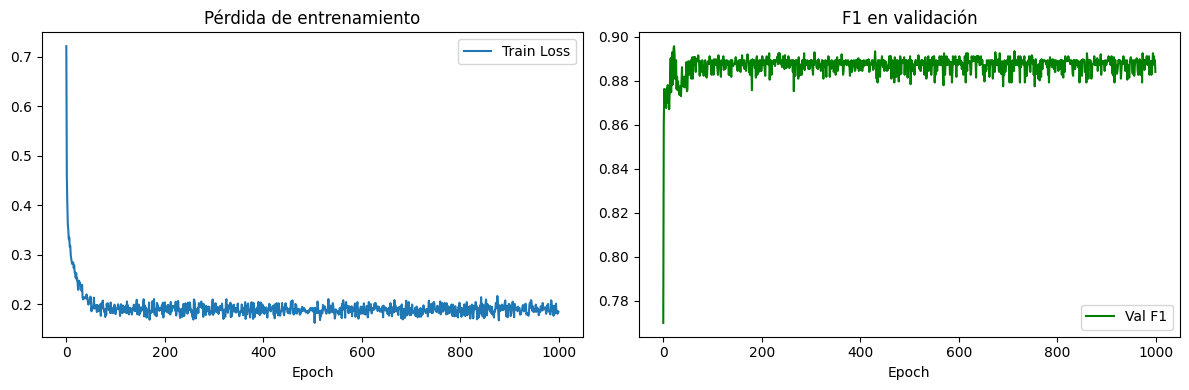

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].set_title('Pérdida de entrenamiento')
axes[1].plot(history['val_f1'], label='Val F1', color='green')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].set_title('F1 en validación')
plt.tight_layout()
plt.show()

In [10]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
torch.save({
    'model_state': model.state_dict(),
    'input_dim': X.shape[1],
    'hidden_dims': (64, 32),
    'feature_cols': FEATURE_COLS
}, '../models/model_derroche.pt')
joblib.dump(scaler, '../models/scaler_derroche.joblib')
print("Checkpoint guardado en models/")

Checkpoint guardado en models/
